# Module 4 — Belief Dynamics & Theory of Mind

**Research Question**: How do LLM beliefs about opponents evolve over rounds? Do beliefs predict actions? Are beliefs well-calibrated?

**Key Finding**: GPT is pessimistic (14% coop belief) and defects accordingly; Mistral/Qwen are optimistic (~56%) but still defect ~50% — revealing a belief-action gap.

**Outputs**: Figure 4a (belief trajectories), Figure 4b (noise suspicion calibration), Figure 4c (belief-action scatter), Figure 4d (belief updating)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ast
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MODEL_COLORS = {
    'GPT-oss-20B': '#E69F00',
    'Mistral-7B': '#56B4E9',
    'Qwen2.5-32B': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
NOISE_LABELS = {0.0: '0%', 0.05: '5%', 0.2: '20%'}
PERSONALITY_MAP = {
    'cooperative': 'Cooperative', 'selfish': 'Selfish',
    'coopératif': 'Cooperative', 'égoïste': 'Selfish',
    'متعاون': 'Cooperative', 'أناني': 'Selfish',
    '合作型的': 'Cooperative', '自私型的': 'Selfish',
    'một người hợp tác': 'Cooperative', 'một người ích kỷ': 'Selfish',
    'cooperativo': 'Cooperative', 'egoista': 'Selfish'
}
FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
DATA_PATH = '../resources/results/Prisoner_dilemma_2player/consolidated_dataset.csv'
df = pd.read_csv(DATA_PATH)
df['personality'] = df['agent1_personality'].map(PERSONALITY_MAP)
df['model'] = df['agent1_llm'].map(MODEL_LABELS)

# Parse list columns
list_cols = ['agent1_opponent_coop_probs', 'agent1_noise_suspicions',
             'agent1_strategies', 'agent2_strategies',
             'agent2_opponent_coop_probs', 'agent2_noise_suspicions']
for col in list_cols:
    df[col + '_parsed'] = df[col].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

print(f'Loaded {len(df)} games, parsed belief columns.')

Loaded 2160 games, parsed belief columns.


## 4.1 Figure 4a — Belief Trajectories Over 30 Rounds

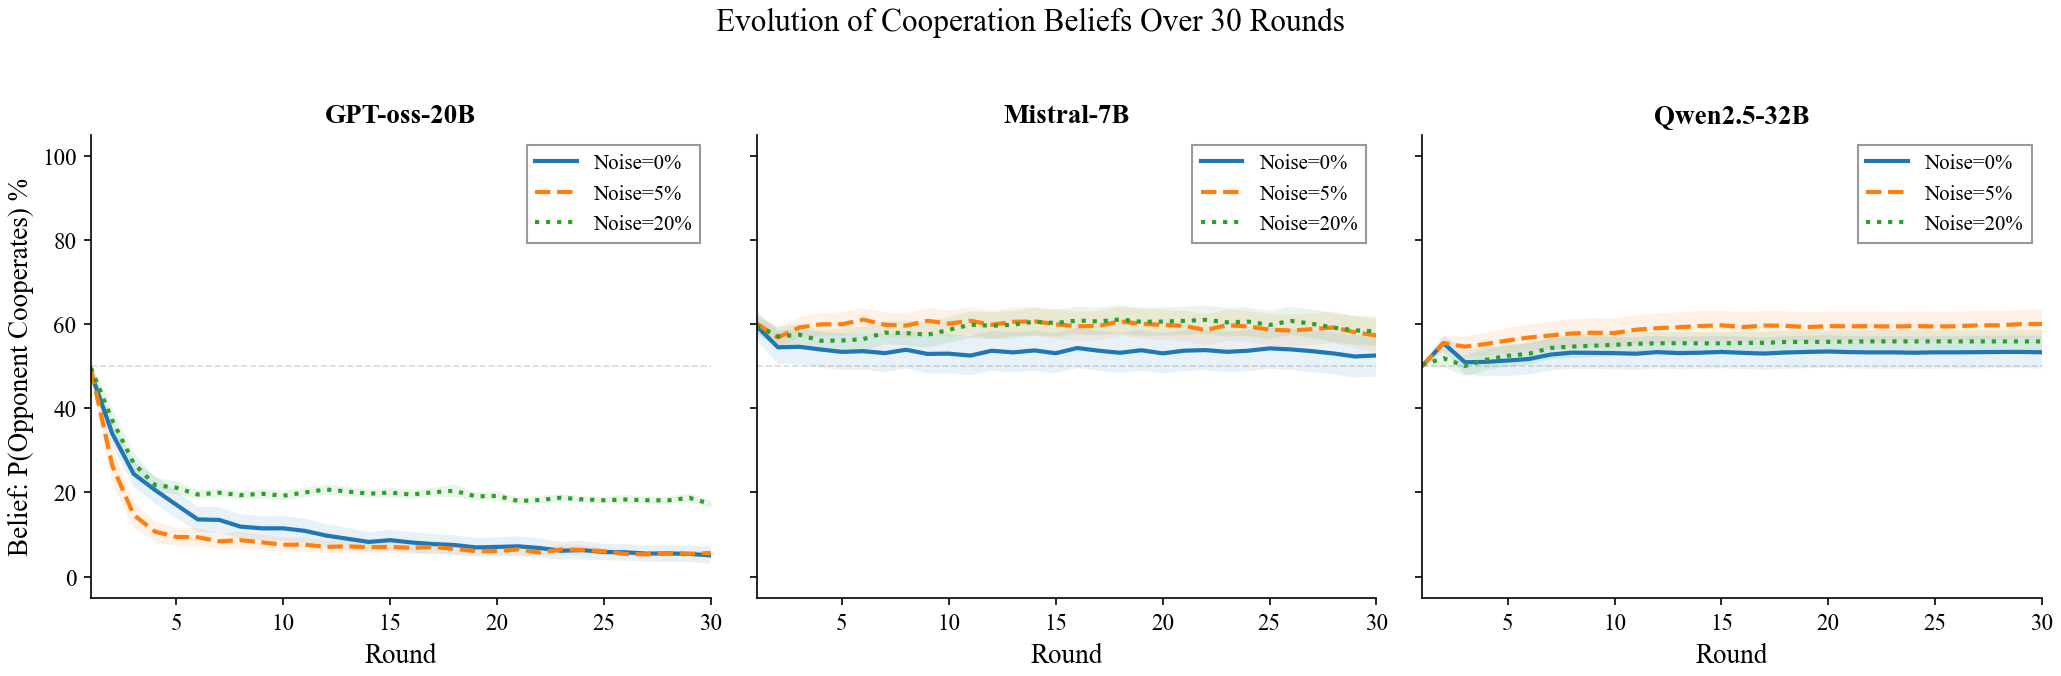

Saved: fig4a_belief_trajectories.pdf/png


In [3]:
# ── Figure 4a: Opponent coop prob belief trajectory per model ──
models_order = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
rounds = np.arange(1, 31)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for idx, model in enumerate(models_order):
    ax = axes[idx]
    sub = df[df['model'] == model]
    
    for noise in [0.0, 0.05, 0.2]:
        noise_sub = sub[sub['agent1_noise_rate'] == noise]
        beliefs = np.array(noise_sub['agent1_opponent_coop_probs_parsed'].tolist())
        # Filter out rows with wrong length
        beliefs = beliefs[[len(b) == 30 for b in beliefs]]
        if len(beliefs) == 0:
            continue
        beliefs = np.vstack(beliefs).astype(float)
        
        mean_belief = np.nanmean(beliefs, axis=0)
        sem_belief = np.nanstd(beliefs, axis=0) / np.sqrt(beliefs.shape[0])
        
        linestyle = '-' if noise == 0.0 else '--' if noise == 0.05 else ':'
        ax.plot(rounds, mean_belief, linewidth=2, linestyle=linestyle,
                label=f'Noise={NOISE_LABELS[noise]}')
        ax.fill_between(rounds,
                        mean_belief - 1.96 * sem_belief,
                        mean_belief + 1.96 * sem_belief, alpha=0.1)
    
    ax.set_xlabel('Round')
    ax.set_title(model, fontsize=13, fontweight='bold')
    ax.set_xlim(1, 30)
    ax.set_ylim(-5, 105)
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.legend(loc='best', frameon=True, fancybox=False, edgecolor='gray', fontsize=10)

axes[0].set_ylabel('Belief: P(Opponent Cooperates) %')
fig.suptitle('Evolution of Cooperation Beliefs Over 30 Rounds', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig4a_belief_trajectories.pdf')
fig.savefig(f'{FIGURE_DIR}fig4a_belief_trajectories.png')
plt.show()
print('Saved: fig4a_belief_trajectories.pdf/png')

## 4.2 Figure 4b — Noise Suspicion Calibration

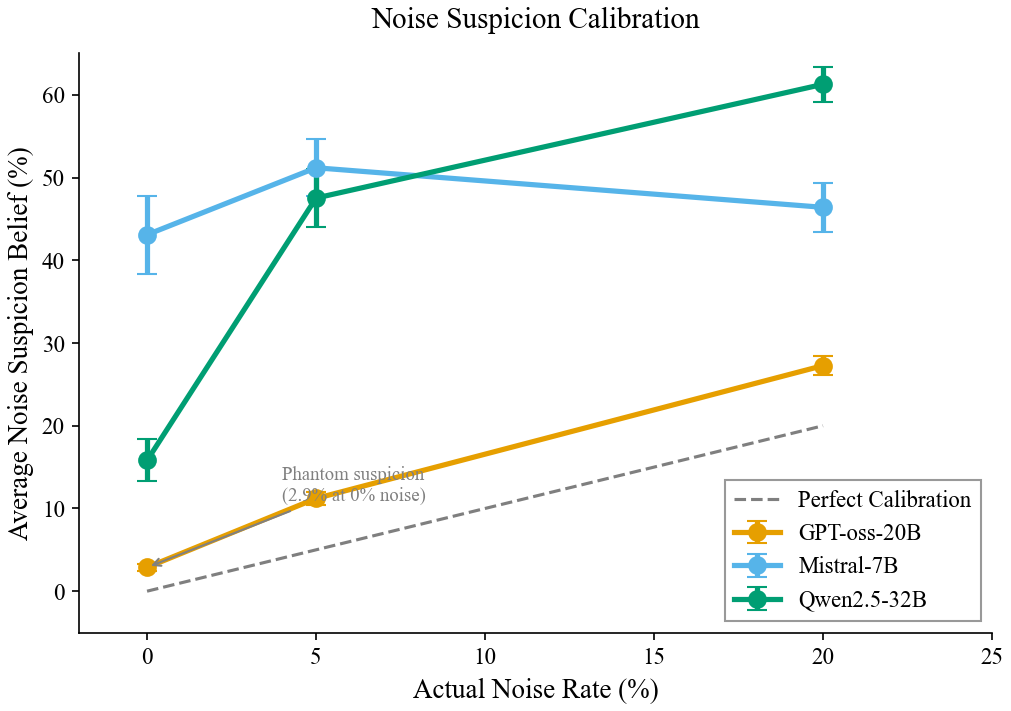

Saved: fig4b_noise_calibration.pdf/png


In [4]:
# ── Figure 4b: Noise suspicion vs actual noise rate (calibration) ──
fig, ax = plt.subplots(figsize=(7, 5))

for model in models_order:
    sub = df[df['model'] == model]
    means = [sub[sub['agent1_noise_rate'] == n]['agent1_avg_noise_suspicion'].mean() for n in [0.0, 0.05, 0.2]]
    sems = [sub[sub['agent1_noise_rate'] == n]['agent1_avg_noise_suspicion'].sem() for n in [0.0, 0.05, 0.2]]
    
    ax.errorbar([0, 5, 20], means, yerr=np.array(sems) * 1.96,
                marker='o', markersize=8, linewidth=2.5, capsize=5,
                color=MODEL_COLORS[model], label=model)

# Perfect calibration line
ax.plot([0, 5, 20], [0, 5, 20], 'k--', linewidth=1.5, alpha=0.5, label='Perfect Calibration')

ax.set_xlabel('Actual Noise Rate (%)')
ax.set_ylabel('Average Noise Suspicion Belief (%)')
ax.set_title('Noise Suspicion Calibration', fontsize=14, pad=12)
ax.legend(frameon=True, fancybox=False, edgecolor='gray')
ax.set_xlim(-2, 25)
ax.set_ylim(-5, 65)

# Annotate miscalibration
for model in models_order:
    sub = df[(df['model'] == model) & (df['agent1_noise_rate'] == 0.0)]
    val = sub['agent1_avg_noise_suspicion'].mean()
    if val > 2:
        ax.annotate(f'Phantom suspicion\n({val:.1f}% at 0% noise)',
                    xy=(0, val), xytext=(4, val + 8),
                    arrowprops=dict(arrowstyle='->', color='gray'),
                    fontsize=9, color='gray')
        break  # annotate once

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig4b_noise_calibration.pdf')
fig.savefig(f'{FIGURE_DIR}fig4b_noise_calibration.png')
plt.show()
print('Saved: fig4b_noise_calibration.pdf/png')

## 4.3 Figure 4c — Belief-Action Consistency

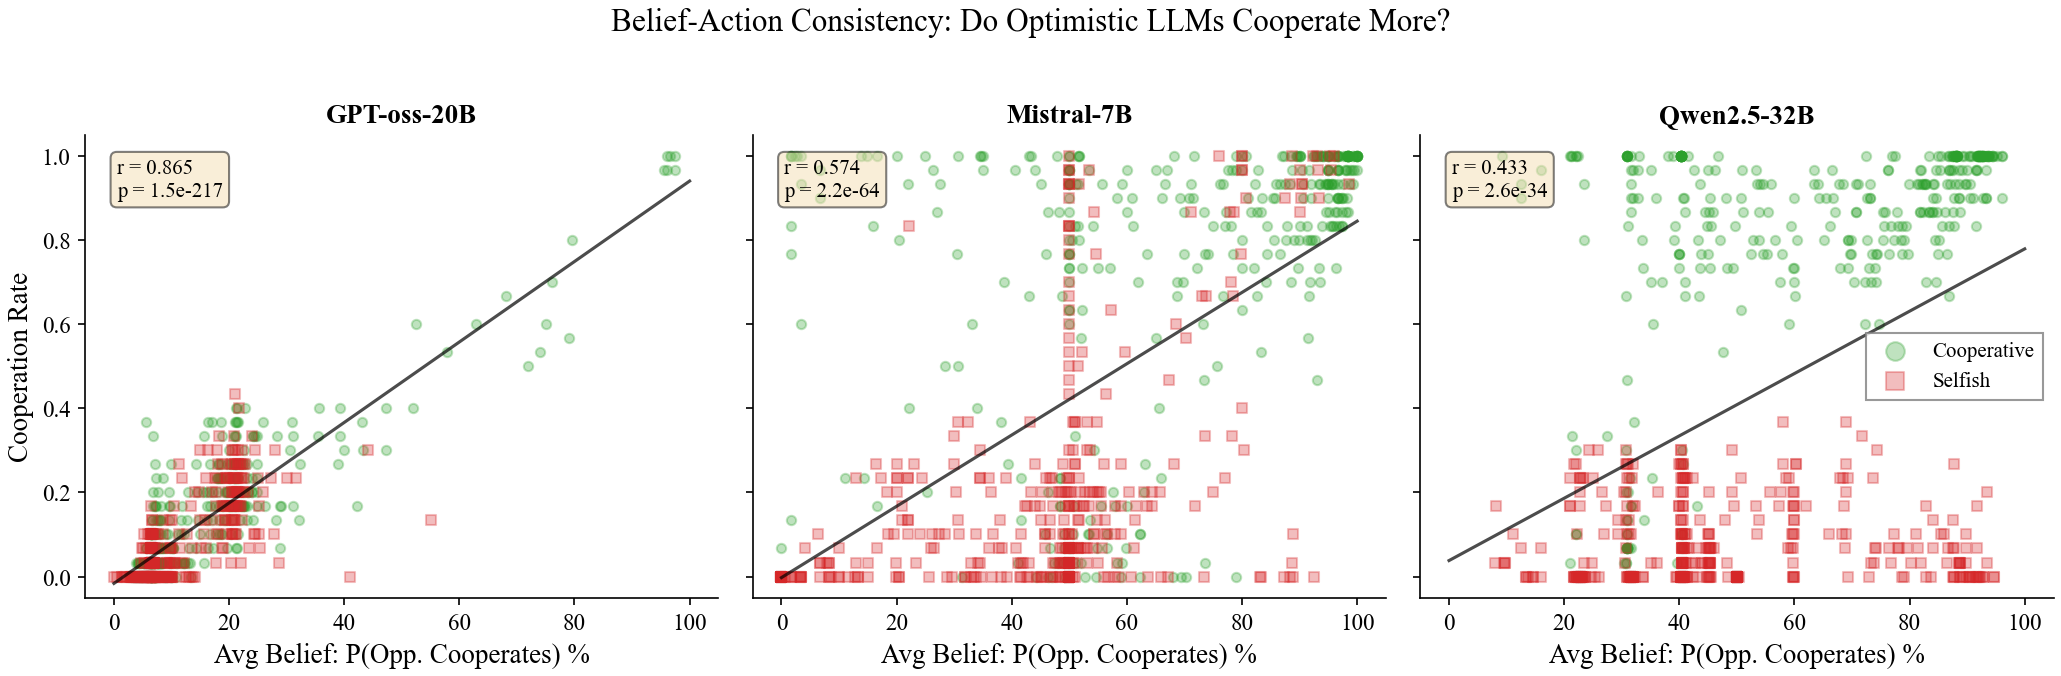

Saved: fig4c_belief_action_scatter.pdf/png


In [5]:
# ── Figure 4c: Per-game scatter — avg belief vs cooperation rate ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for idx, model in enumerate(models_order):
    ax = axes[idx]
    sub = df[df['model'] == model].copy()
    
    for pers, marker, color in [('Cooperative', 'o', '#2ca02c'), ('Selfish', 's', '#d62728')]:
        ps = sub[sub['personality'] == pers]
        ax.scatter(ps['agent1_avg_opponent_coop_prob'], ps['agent1_cooperation_rate'],
                   alpha=0.3, s=20, marker=marker, color=color, label=pers)
    
    # Regression line (all data)
    valid = sub.dropna(subset=['agent1_avg_opponent_coop_prob', 'agent1_cooperation_rate'])
    if len(valid) > 2:
        slope, intercept, r, p, se = stats.linregress(
            valid['agent1_avg_opponent_coop_prob'], valid['agent1_cooperation_rate']
        )
        x_line = np.linspace(0, 100, 100)
        ax.plot(x_line, intercept + slope * x_line, 'k-', linewidth=1.5, alpha=0.7)
        ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.1e}',
                transform=ax.transAxes, fontsize=10, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Avg Belief: P(Opp. Cooperates) %')
    ax.set_title(model, fontsize=13, fontweight='bold')
    ax.set_xlim(-5, 105)
    ax.set_ylim(-0.05, 1.05)
    if idx == 2:
        ax.legend(loc='center right', frameon=True, fancybox=False,
                  edgecolor='gray', fontsize=10, markerscale=2)

axes[0].set_ylabel('Cooperation Rate')
fig.suptitle('Belief-Action Consistency: Do Optimistic LLMs Cooperate More?', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig4c_belief_action_scatter.pdf')
fig.savefig(f'{FIGURE_DIR}fig4c_belief_action_scatter.png')
plt.show()
print('Saved: fig4c_belief_action_scatter.pdf/png')

## 4.4 Figure 4d — Belief Updating After Opponent Actions

In [6]:
# ── Figure 4d: How beliefs change after seeing opponent cooperate/defect ──
# Compute belief_delta_{t+1} = belief_{t+1} - belief_t, conditioned on opponent action at t

update_rows = []
for _, row in df.iterrows():
    beliefs = row['agent1_opponent_coop_probs_parsed']
    opp_strats = row['agent2_strategies_parsed']
    model = row['model']
    
    if len(beliefs) != 30 or len(opp_strats) != 30:
        continue
    
    for t in range(29):  # rounds 0-28
        try:
            b_t = float(beliefs[t])
            b_t1 = float(beliefs[t + 1])
        except (ValueError, TypeError):
            continue
        delta = b_t1 - b_t
        opp_action = 'Cooperated' if opp_strats[t] == 'OptionB' else 'Defected'
        update_rows.append({
            'model': model, 'round': t + 1,
            'belief_delta': delta, 'opp_action': opp_action
        })

updates_df = pd.DataFrame(update_rows)
print(f'Total belief updates: {len(updates_df):,}')
print(updates_df.groupby(['model', 'opp_action'])['belief_delta'].describe().round(2))

Total belief updates: 60,649
                          count  mean    std    min  25%  50%  75%    max
model       opp_action                                                   
GPT-oss-20B Cooperated   2159.0  3.86  14.61  -90.0  0.0  0.0  5.0   92.0
            Defected    17241.0 -1.95   9.68  -94.0  0.0  0.0  0.0   90.0
Mistral-7B  Cooperated   9930.0  0.27  12.09 -100.0  0.0  0.0  0.0  100.0
            Defected    10653.0 -0.53  11.29 -100.0  0.0  0.0  0.0  100.0
Qwen2.5-32B Cooperated   9292.0  1.50   4.98  -20.0  0.0  0.0  0.0   75.0
            Defected    11374.0 -0.86   4.22  -50.0  0.0  0.0  0.0   65.0


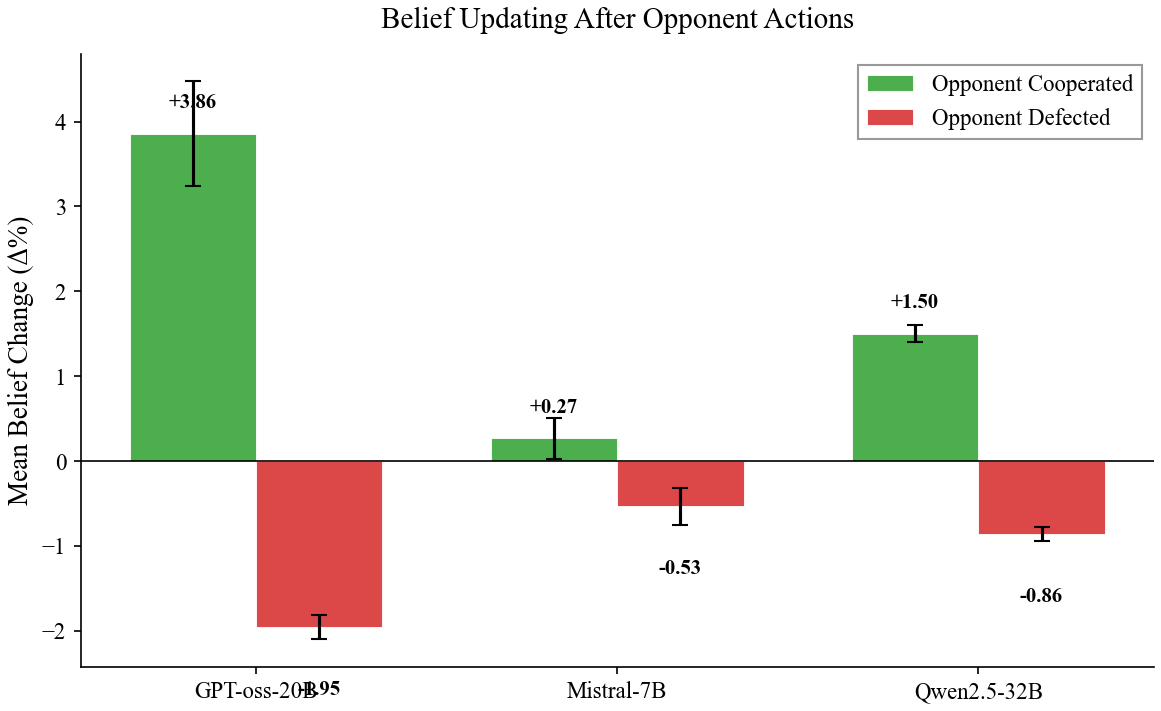

Saved: fig4d_belief_updating.pdf/png


In [7]:
# ── Figure 4d: Belief update magnitude by opponent action ──
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(models_order))
width = 0.35

for i, action in enumerate(['Cooperated', 'Defected']):
    means = []
    sems = []
    for model in models_order:
        sub = updates_df[(updates_df['model'] == model) & (updates_df['opp_action'] == action)]
        means.append(sub['belief_delta'].mean())
        sems.append(sub['belief_delta'].sem())
    
    color = '#2ca02c' if action == 'Cooperated' else '#d62728'
    ax.bar(x + (i - 0.5) * width, means, width,
           yerr=np.array(sems) * 1.96, capsize=4,
           label=f'Opponent {action}', color=color, alpha=0.85,
           edgecolor='white', linewidth=0.5)
    
    for j, (m, s) in enumerate(zip(means, sems)):
        ax.text(x[j] + (i - 0.5) * width, m + (0.3 if m > 0 else -0.8),
                f'{m:+.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_order)
ax.set_ylabel('Mean Belief Change (Δ%)')
ax.set_title('Belief Updating After Opponent Actions', fontsize=14, pad=12)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.legend(frameon=True, fancybox=False, edgecolor='gray')

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig4d_belief_updating.pdf')
fig.savefig(f'{FIGURE_DIR}fig4d_belief_updating.png')
plt.show()
print('Saved: fig4d_belief_updating.pdf/png')

## 4.5 Calibration Summary Table

In [8]:
# ── Table: Belief calibration summary ──
calib_rows = []
for model in models_order:
    for noise in [0.0, 0.05, 0.2]:
        sub = df[(df['model'] == model) & (df['agent1_noise_rate'] == noise)]
        avg_belief = sub['agent1_avg_opponent_coop_prob'].mean()
        avg_suspicion = sub['agent1_avg_noise_suspicion'].mean()
        actual_opp_coop = sub['agent2_cooperation_rate'].mean()
        belief_error = avg_belief - (actual_opp_coop * 100)
        suspicion_error = avg_suspicion - (noise * 100)
        
        calib_rows.append({
            'Model': model, 'Noise': NOISE_LABELS[noise],
            'Avg Coop Belief (%)': round(avg_belief, 1),
            'Actual Opp Coop (%)': round(actual_opp_coop * 100, 1),
            'Belief Error': round(belief_error, 1),
            'Avg Noise Suspicion (%)': round(avg_suspicion, 1),
            'Actual Noise (%)': noise * 100,
            'Suspicion Error': round(suspicion_error, 1)
        })

calib_df = pd.DataFrame(calib_rows)
display(calib_df)

,Model,Noise,Avg Coop Belief (%),Actual Opp Coop (%),Belief Error,Avg Noise Suspicion (%),Actual Noise (%),Suspicion Error
0,GPT-oss-20B,0%,11.7,6.3,5.4,2.9,0.0,2.9
1,GPT-oss-20B,5%,9.7,8.3,1.4,11.2,5.0,6.2
2,GPT-oss-20B,20%,21.6,22.1,-0.5,27.3,20.0,7.3
3,Mistral-7B,0%,53.8,52.2,1.6,43.1,0.0,43.1
4,Mistral-7B,5%,59.5,47.0,12.6,51.2,5.0,46.2
5,Mistral-7B,20%,59.3,47.1,12.2,46.4,20.0,26.4
6,Qwen2.5-32B,0%,53.0,39.0,14.0,15.8,0.0,15.8
7,Qwen2.5-32B,5%,58.3,46.3,12.0,47.5,5.0,42.5
8,Qwen2.5-32B,20%,54.8,49.6,5.2,61.3,20.0,41.3
